# F_waveform_space_tetrode.ipynb

## Purpose

Identical waveform analysis applied exclusively to tetrode-recorded units, producing the same spatial feature maps for the tetrode recording subset.

## Manuscript figure panels

- FigA13 g-i

## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_unit_tbl.pkl` (Step 1)
- `combined_waveform_TT.pkl` (Step 3b)

In [1]:
import sys
import os
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import os
import sys
_beh_ephys_root = os.path.normpath(os.path.join(os.getcwd(), '..', '..'))
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
from harp.clock import decode_harp_clock, align_timestamps_to_anchor_points
from open_ephys.analysis import Session
import datetime
from aind_ephys_rig_qc.temporal_alignment import search_harp_line
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
import ast
from utils.plot_utils import combine_pdf_big

from open_ephys.analysis import Session
from pathlib import Path
import glob

import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from aind_dynamic_foraging_basic_analysis.plot.plot_foraging_session import plot_foraging_session
from aind_dynamic_foraging_data_utils.nwb_utils import load_nwb_from_filename
from hdmf_zarr.nwb import NWBZarrIO
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps
from utils.combine_tools import apply_qc
from utils.capsule_migration import capsule_directories
import pandas as pd
import pickle
import scipy.stats as stats
from joblib import Parallel, delayed
from multiprocessing import Pool
from functools import partial
import time
import spikeinterface as si
import shutil 
import seaborn as sns
import math  
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import zscore
from trimesh import load_mesh
from scipy.optimize import minimize
from scipy.linalg import null_space
from joblib import Parallel, delayed
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Data Loading and Configuration

Load the combined unit table containing all quality-controlled tetrode units and apply waveform-specific quality criteria. The waveform quality constraints filter units based on spike shape characteristics to ensure clean, reliable waveforms for downstream analysis.

In [2]:
criteria_name = 'waveform_TT'
waveform_version = '_raw' # 'wf_2D' for 'wf_2D_raw'

In [3]:
# load constraints and data
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)
wf_folder = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'waveform_tt')
if not os.path.exists(wf_folder):
    os.makedirs(wf_folder)

target_folder = os.path.join(capsule_dirs['manuscript_fig_prep_dir'], 'F_waveforms_tt')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)


## Quality Control Filtering

Apply quality metrics to filter tetrode units based on waveform characteristics and ISI violations. This produces visualizations showing the distribution of quality metrics and the relationship between optogenetic tagging confidence and waveform quality measures.

Applying bounds for isi_violations: [0.0, 0.5]
 - isi_violations: 15125 -> 9428 units passed
Applying items for qc_pass: [True]
 - qc_pass: 9428 -> 6623 units passed
Applying bounds for peak_raw: ['NaN', -50]
 - peak_raw: 6623 -> 865 units passed
Applying items for probe: ['tt']
 - probe: 865 -> 191 units passed
Applying conditional bounds for y_loc
 - y_loc: 191 -> 191 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']


Number of opto rows after filtering: 113
Number of non-opto rows after filtering: 191


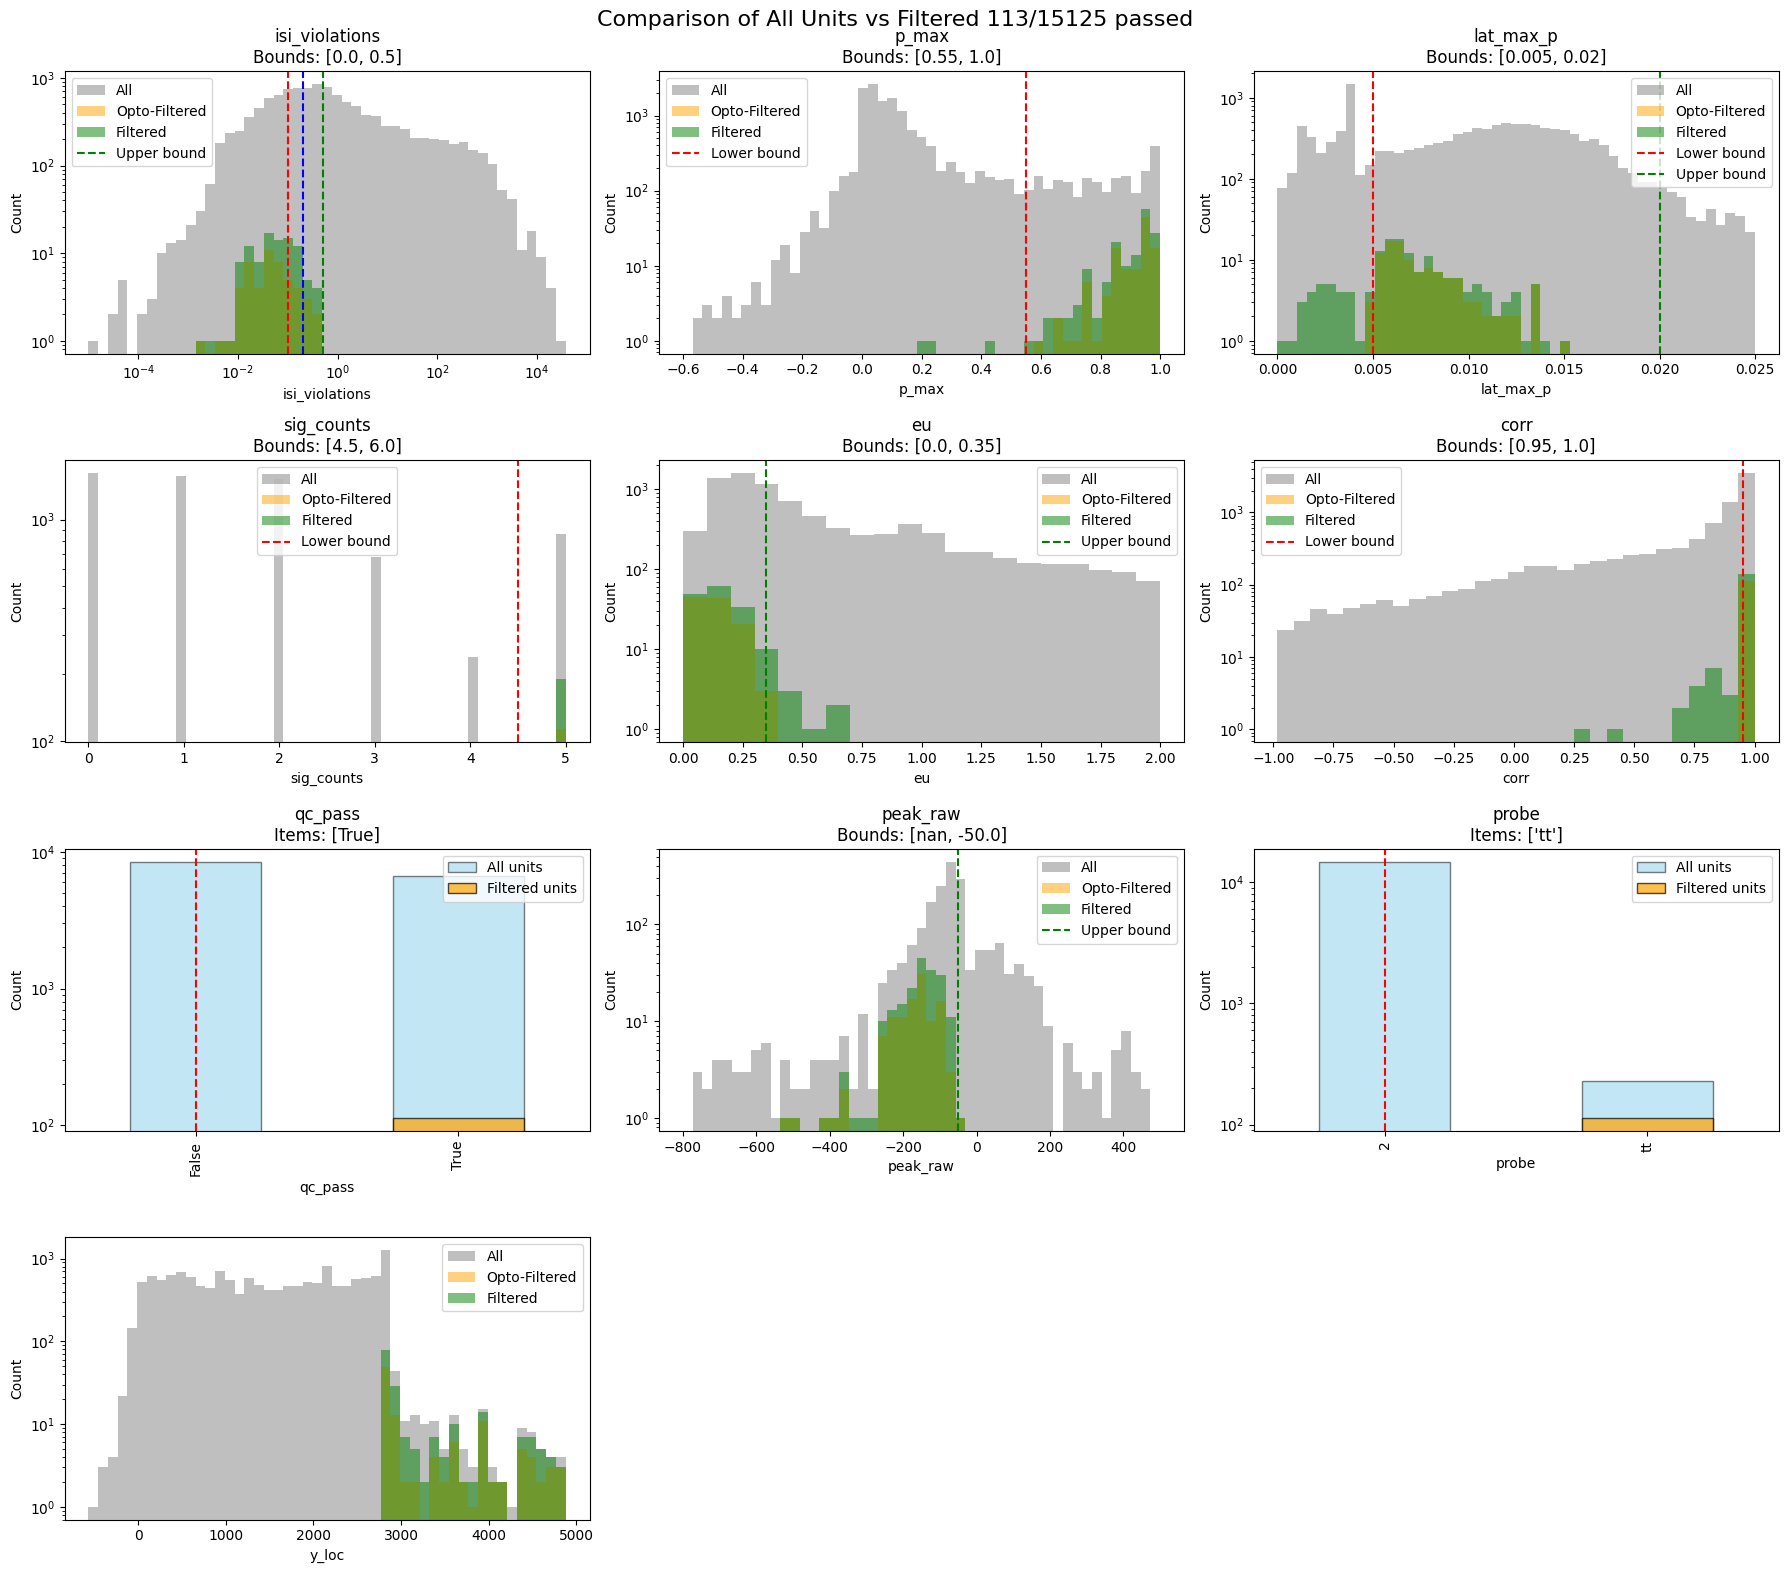

In [4]:
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints, density=False)
fig.savefig(os.path.join(target_folder, f'quality_metrics_combined_units_{criteria_name}_waveformQC.pdf'), dpi=300)

In [5]:
mask = np.full(len(combined_tagged_units_filtered), True)
aniNames = [parseSessionID(session_curr)[0] for session_curr in combined_tagged_units_filtered[mask]['session']]
print(f"Animals count: {len(set(aniNames))}")
print(f"Session count: {len(combined_tagged_units_filtered[mask]['session'].unique())}")
print(f"Unit count: {len(combined_tagged_units_filtered[mask])}")

Animals count: 3
Session count: 63
Unit count: 113


## Waveform Feature Extraction

Extract comprehensive features from each unit's spike waveform including peak width, trough characteristics, and symmetry measures. These features capture the temporal dynamics of the action potential shape which may vary systematically across the dorsal-ventral axis. Key features include:
- Half-width and trough width measurements
- Pre/post-peak symmetry and slope ratios
- Temporal integration measures (space under the curve)

In [7]:
def zero_crossings_linear(x, y):
    """
    Find x positions where y crosses zero using linear interpolation.

    Parameters
    ----------
    x, y : 1D arrays of same length

    Returns
    -------
    x0 : 1D array
        x positions of zero crossings
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if x.ndim != 1 or y.ndim != 1 or len(x) != len(y):
        raise ValueError("x and y must be 1D arrays of the same length")

    # Find sign changes (exclude exact zeros handled below)
    sign_change = (y[:-1] * y[1:] < 0)

    x0 = x[:-1][sign_change] - y[:-1][sign_change] * (
        x[1:][sign_change] - x[:-1][sign_change]
    ) / (
        y[1:][sign_change] - y[:-1][sign_change]
    )

    # Handle exact zeros (y == 0)
    exact = np.where(y == 0)[0]
    if exact.size > 0:
        x0 = np.sort(np.concatenate([x0, x[exact]]))

    return x0


In [8]:
# Extract waveform feature
wf_norm = []
wf_2D_norm = []

half_w = []
trough_w = []
pre_half = []
post_half = []
post_w = []

trough_post_ratio_1D = []
trough_pre_ratio_1D = []

post_slope = []
post_trough_slope = []
post_space = []
post_space_raw = []
pre_slope = []
pre_space = []
pre_space_raw = []

symmetry_inte = []
symmetry_half = []
symmetry_slope = []
symmetry_inte_div = []
symmetry_half_div = []
symmetry_slope_div = []
symmetry_space_raw_div = []
symmetry_trough_dis = []

trough_sum = []
slope_sum = []

# wf_norm = combined_tagged_units_filtered['wf']/np.abs(combined_tagged_units_filtered['peak'])
# wf_2D_norm = combined_tagged_units_filtered['wf_2d']/np.abs(combined_tagged_units_filtered['peak'])

wf_norm = combined_tagged_units_filtered[f'wf{waveform_version}']/np.abs(combined_tagged_units_filtered[f'peak{waveform_version}'])
# wf_2D_norm = combined_tagged_units_filtered['wf_2d']/np.abs(combined_tagged_units_filtered['peak'])
for rows in combined_tagged_units_filtered.iterrows():
    print(f'Processing unit {rows[1]["unit"]} of session {rows[1]["session"]}')
    # wf = rows[1]['wf']
    # peak = rows[1]['peak']
    # print(rows[1]['session'])
    # print(rows[1]['unit'])
    wf = rows[1][f'wf{waveform_version}'][:32*5]
    wf_bl = np.nanmean(wf[:5])
    peak = rows[1][f'peak{waveform_version}'] - wf_bl
    wf = wf - wf_bl
    peak_ind = np.argmin(wf)

    if np.abs(wf[0]-wf[-1])>50:
        half_w.append(np.nan)  # half width in samples
        trough_w.append(np.nan)  # trough width in samples
        post_w.append(np.nan)  # post trough width in samples
        pre_half.append(np.nan)
        post_half.append(np.nan)
        trough_post_ratio_1D.append(np.nan)
        trough_pre_ratio_1D.append(np.nan)
        post_slope.append(np.nan)
        post_trough_slope.append(np.nan)
        post_space.append(np.nan)
        pre_slope.append(np.nan)
        pre_space.append(np.nan)
        symmetry_inte.append(np.nan)
        symmetry_half.append(np.nan)
        symmetry_slope.append(np.nan)
        symmetry_inte_div.append(np.nan)
        symmetry_half_div.append(np.nan)
        symmetry_slope_div.append(np.nan)
        symmetry_space_raw_div.append(np.nan)
        symmetry_trough_dis.append(np.nan)
        post_space_raw.append(np.nan)
        pre_space_raw.append(np.nan)
        continue

    if peak<0:
        curr_trough_loc = np.argmax(wf[peak_ind:])+1
        post_trough = np.max(wf[peak_ind:])
        post_trough_ind = np.argmax(wf[peak_ind:])+1
        pre_trough = np.max(wf[:peak_ind])
        pre_trough_ind = peak_ind - np.argmax(wf[:peak_ind])  
    else:
        curr_trough_loc = np.argmin(wf[peak_ind:])+1
        post_trough = np.min(wf[peak_ind:])
        post_trough_ind = np.argmin(wf[peak_ind:])+1
        pre_trough = np.min(wf[:peak_ind])
        pre_trough_ind = peak_ind - np.argmin(wf[:peak_ind])  
    curr_trough_post = post_trough/peak # positive if same sign, negative if opposite sign
    curr_trough_pre = pre_trough/peak # positive if same sign, negative if opposite sign
    curr_trough_loc_slope_post = ((peak - post_trough)/peak)/post_trough_ind
    curr_trough_slope = (post_trough/peak)/post_trough_ind
    curr_trough_loc_inte_post = ((post_trough)/peak)*post_trough_ind
    curr_trough_loc_slope_pre = ((peak - pre_trough)/peak)/pre_trough_ind # positive if same sign, negative if opposite sign
    curr_trough_loc_inte_pre = ((pre_trough)/peak)*pre_trough_ind # positive if same sign, negative if opposite sign
    pre_peak_wf = wf[:peak_ind]
    post_peak_wf = wf[peak_ind:]
    curr_pre_space_raw = np.sum(pre_peak_wf[pre_peak_wf>0])
    curr_post_space_raw = np.sum(post_peak_wf[post_peak_wf>0])

    curr_symmetry_inte = curr_trough_loc_inte_post - curr_trough_loc_inte_pre  # positive if same sign, negative if opposite sign
    curr_symmetry_slope = curr_trough_loc_slope_post - curr_trough_loc_slope_pre  # positive if same sign, negative if opposite sign
    
    curr_trough_sum = (curr_pre_space_raw + curr_post_space_raw)/peak
    curr_slope_sum = curr_trough_loc_slope_post + curr_trough_loc_slope_pre  

    # find samples where the waveform crosses the half peak threshold to infer half width
    half_peak = peak / 2
    # wf_half_crossings = np.where(np.diff(np.sign(wf - half_peak))!=0)[0]+1  # indices where waveform crosses half peak
    wf_half_crossings = zero_crossings_linear(np.arange(len(wf)), wf - half_peak)
    if len(wf_half_crossings) < 2:
        post_crossing = np.nan
        pre_crossing = np.nan
    else: 
        if np.all(wf_half_crossings < peak_ind) or np.all(wf_half_crossings > peak_ind):
            post_crossing = np.nan
            pre_crossing = np.nan
        else:
            post_crossing = np.min(wf_half_crossings[wf_half_crossings > peak_ind]) - peak_ind
            pre_crossing = peak_ind - np.max(wf_half_crossings[wf_half_crossings < peak_ind])

    half_w.append(post_crossing + pre_crossing)  # half width in samples
    trough_w.append(post_trough_ind + pre_trough_ind)  # trough width in samples
    post_w.append(post_trough_ind)  # post trough width in samples
    pre_half.append(pre_crossing)
    post_half.append(post_crossing)

    trough_post_ratio_1D.append(curr_trough_post)
    trough_pre_ratio_1D.append(curr_trough_pre)

    post_slope.append(curr_trough_loc_slope_post)
    post_trough_slope.append(curr_trough_slope)
    post_space.append(curr_trough_loc_inte_post)
    pre_slope.append(curr_trough_loc_slope_pre)
    pre_space.append(curr_trough_loc_inte_pre)    
    post_space_raw.append(curr_post_space_raw)
    pre_space_raw.append(curr_pre_space_raw)

    symmetry_inte.append(curr_trough_loc_inte_post - curr_trough_loc_inte_pre)
    symmetry_half.append(post_crossing - pre_crossing)
    symmetry_slope.append(curr_trough_loc_slope_post - curr_trough_loc_slope_pre)

    symmetry_inte_div.append(curr_trough_loc_inte_post/curr_trough_loc_inte_pre)
    symmetry_half_div.append(post_crossing/pre_crossing)
    symmetry_slope_div.append(curr_trough_loc_slope_post/curr_trough_loc_slope_pre)
    symmetry_space_raw_div.append(curr_post_space_raw/curr_pre_space_raw)
    symmetry_trough_dis.append(post_trough_ind - pre_trough_ind)

    trough_sum.append(curr_trough_sum)
    slope_sum.append(curr_slope_sum)


wf_features = pd.DataFrame({'unit_id': combined_tagged_units_filtered['unit'],
                            'session': combined_tagged_units_filtered['session'],
                            'amp': combined_tagged_units_filtered['amp'],
                            'peak': combined_tagged_units_filtered['peak'],
                            'half_w': half_w,
                            'trough_w': trough_w,
                            'pre_half': pre_half,
                            'post_half': post_half,
                            'post_w': post_w,
                            'trough_post_ratio_1D': trough_post_ratio_1D,
                            'trough_pre_ratio_1D': trough_pre_ratio_1D,
                            'post_slope': post_slope,
                            'post_trough_slope': post_trough_slope,
                            'post_space': post_space,
                            'pre_slope': pre_slope,
                            'pre_space': pre_space,
                            'symmetry_inte': symmetry_inte,
                            'symmetry_half': symmetry_half,
                            'symmetry_slope': symmetry_slope,
                            'symmetry_inte_div': symmetry_inte_div,
                            'symmetry_half_div': symmetry_half_div,
                            'symmetry_slope_div': symmetry_slope_div,
                            'symmetry_space_raw_div': symmetry_space_raw_div,
                            'symmetry_trough_dis': symmetry_trough_dis,
                            'trough_sum': trough_sum,
                            'slope_sum': slope_sum,
                            'y_loc': combined_tagged_units_filtered['y_loc'],
                            'probe': combined_tagged_units_filtered['probe'],
                            })
wf_features['symmetry_inte_div_log'] = np.log(wf_features['symmetry_inte_div'] + 1e-6)
wf_features['symmetry_slope_div_log'] = np.log(wf_features['symmetry_slope_div'] + 1e-6)
wf_features['symmetry_half_div_log'] = np.log(wf_features['symmetry_half_div'] + 1e-6)
wf_features.rename(columns={'unit_id': 'unit'}, inplace=True)
combined_features = wf_features.merge(combined_tagged_units_filtered[['session', 'unit', 'x_ccf', 'y_ccf', 'z_ccf', 'isi_violations']], on=['session', 'unit'], how='left')                         


Processing unit TT4_SS_02 of session behavior_ZS059_2021-03-28_14-18-58
Processing unit TT4_SS_01 of session behavior_ZS059_2021-03-29_14-41-57
Processing unit TT4_SS_01 of session behavior_ZS059_2021-03-30_14-57-13
Processing unit TT4_SS_02 of session behavior_ZS059_2021-03-31_14-32-51
Processing unit TT4_SS_01 of session behavior_ZS059_2021-04-01_14-17-46
Processing unit TT4_SS_01 of session behavior_ZS059_2021-04-10_15-55-11
Processing unit TT4_SS_01 of session behavior_ZS059_2021-04-15_15-29-28
Processing unit TT4_SS_01 of session behavior_ZS059_2021-04-21_15-58-55
Processing unit TT4_SS_02 of session behavior_ZS059_2021-04-22_15-11-25
Processing unit TT3_SS_01 of session behavior_ZS061_2021-03-20_18-03-26
Processing unit TT4_SS_01 of session behavior_ZS061_2021-03-20_18-03-26
Processing unit TT3_SS_03 of session behavior_ZS061_2021-03-22_17-35-53
Processing unit TT4_SS_01 of session behavior_ZS061_2021-03-22_17-35-53
Processing unit TT1_SS_02 of session behavior_ZS061_2021-03-23_1

/opt/conda/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [9]:
wf_features = pd.read_csv(str(capsule_directories()['derived_dir']) + '/results/manuscript/prep/waveforms_tt/combined_features.csv')

In [10]:
wf_features.rename(columns={'unit_id': 'unit'}, inplace=True)
combined_features = wf_features.merge(combined_tagged_units_filtered[['session', 'unit', 'x_ccf', 'y_ccf', 'z_ccf', 'isi_violations']], on=['session', 'unit'], how='left')                         


## Waveform Visualization

Visualize all individual waveforms and their normalized forms. Normalization by peak amplitude allows comparison of waveform shapes across units with different firing amplitudes, revealing systematic variations in action potential kinetics.

In [12]:
wf_list = combined_tagged_units_filtered[f'wf{waveform_version}'].values
peak_list = combined_tagged_units_filtered[f'peak{waveform_version}'].values

# Stack waveforms into 2D array (n_units x n_timepoints)
wf_array = np.vstack(wf_list)
wf_array = wf_array[:, :32*5]  # ensure consistent length

# Normalize each row by corresponding peak value
wf_norm = wf_array / peak_list[:, np.newaxis]  # shape: (n_units, n_timepoints)


In [13]:
# grab all tagged units and combine spike waveforms
all_wfs = combined_tagged_units_filtered[f'wf{waveform_version}'].tolist()
# all_wfs_aligned = combined_tagged_units_filtered['wf_aligned'].tolist()
all_peaks = combined_tagged_units_filtered[f'peak{waveform_version}'].tolist()
all_wfs = np.array(all_wfs)[:, :32*5]
# all_wfs_aligned = np.array(all_wfs_aligned)
baseline = np.mean(all_wfs[:, :3], axis=1, keepdims=True) 
peaks = np.array(all_peaks).reshape(-1, 1) 

all_wfs_nl = (all_wfs - baseline) / ((np.squeeze(all_wfs[:, 64]) - np.squeeze(baseline))[:, np.newaxis])
all_wfs_nl_raw = all_wfs/all_wfs[:,64][:, np.newaxis]
all_wfs_nl[all_wfs_nl_raw[:, 0]>1, :] = np.nan  # remove bad waveforms
# all_wfs_aligned_nl = all_wfs_aligned/all_wfs_aligned[:,30].reshape(-1, 1)
all_wfs_nl_clean = all_wfs_nl[~np.isnan(all_wfs_nl[:,0])]


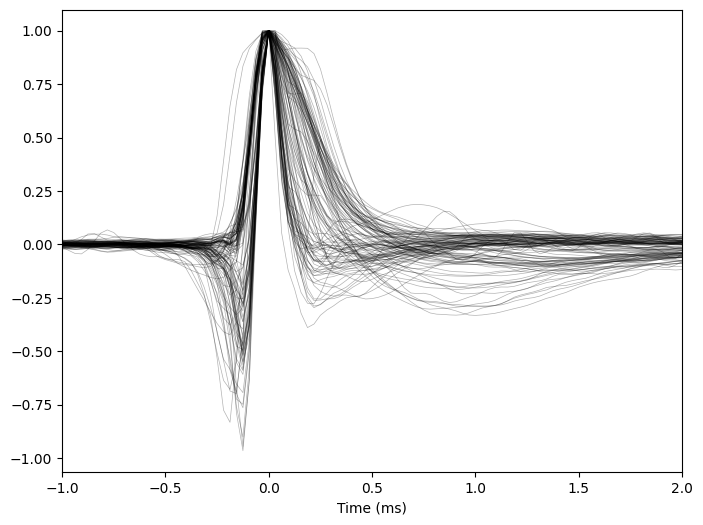

In [15]:
time = (np.arange(0, np.shape(all_wfs_nl_clean)[1])-64)/32
fig = plt.figure(figsize=(8, 6))
plt.plot(time, all_wfs_nl_clean.T, 'k', linewidth=0.5, alpha=0.3);
plt.xlabel('Time (ms)')
plt.xlim(-1, 2)
fig.savefig(os.path.join(target_folder, f'all_waveforms_overlay.pdf'), dpi=300, bbox_inches='tight')

## Waveform Principal Component Analysis

Perform PCA on normalized waveforms to identify the primary axes of waveform shape variation. The first few PCs typically capture differences in spike width and repolarization dynamics that relate to neuronal biophysics and may correlate with anatomical position.

## Clustering and Classification

Apply unsupervised clustering methods (K-means and Gaussian Mixture Models) to identify distinct waveform classes. The goal is to determine whether units naturally separate into discrete groups based on waveform shape, which could indicate functionally or anatomically distinct cell populations.

## Spatial-Waveform Correlations

Test for systematic relationships between waveform features and recording location along the dorsal-ventral axis. Significant correlations would indicate spatial gradients in neuronal properties, potentially reflecting developmental or functional organization within the superior colliculus.

In [22]:
y_loc = combined_tagged_units_filtered['y_loc'].values
animals = ['ZS059', 'ZS060', 'ZS061', 'ZS062']
for animal in animals:
    print(animal)
    ani_session_ind = combined_tagged_units_filtered['session'].str.contains(
                            animal,
                            regex=False,
                            na=False
                        )
    if np.sum(ani_session_ind)==0:
        continue
    y_loc[ani_session_ind] = y_loc[ani_session_ind]  - np.nanmin(y_loc[ani_session_ind])

ZS059
ZS060
ZS061
ZS062


In [23]:
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', 
                                               [(0, (0, 1, 1)), 
                                                (0.5, (0.5, 0.5, 0.5)), 
                                                (1.0, (1, 0, 0))])

In [24]:
# import rankdata
from scipy.stats import rankdata
y_loc_ranked = rankdata(y_loc)


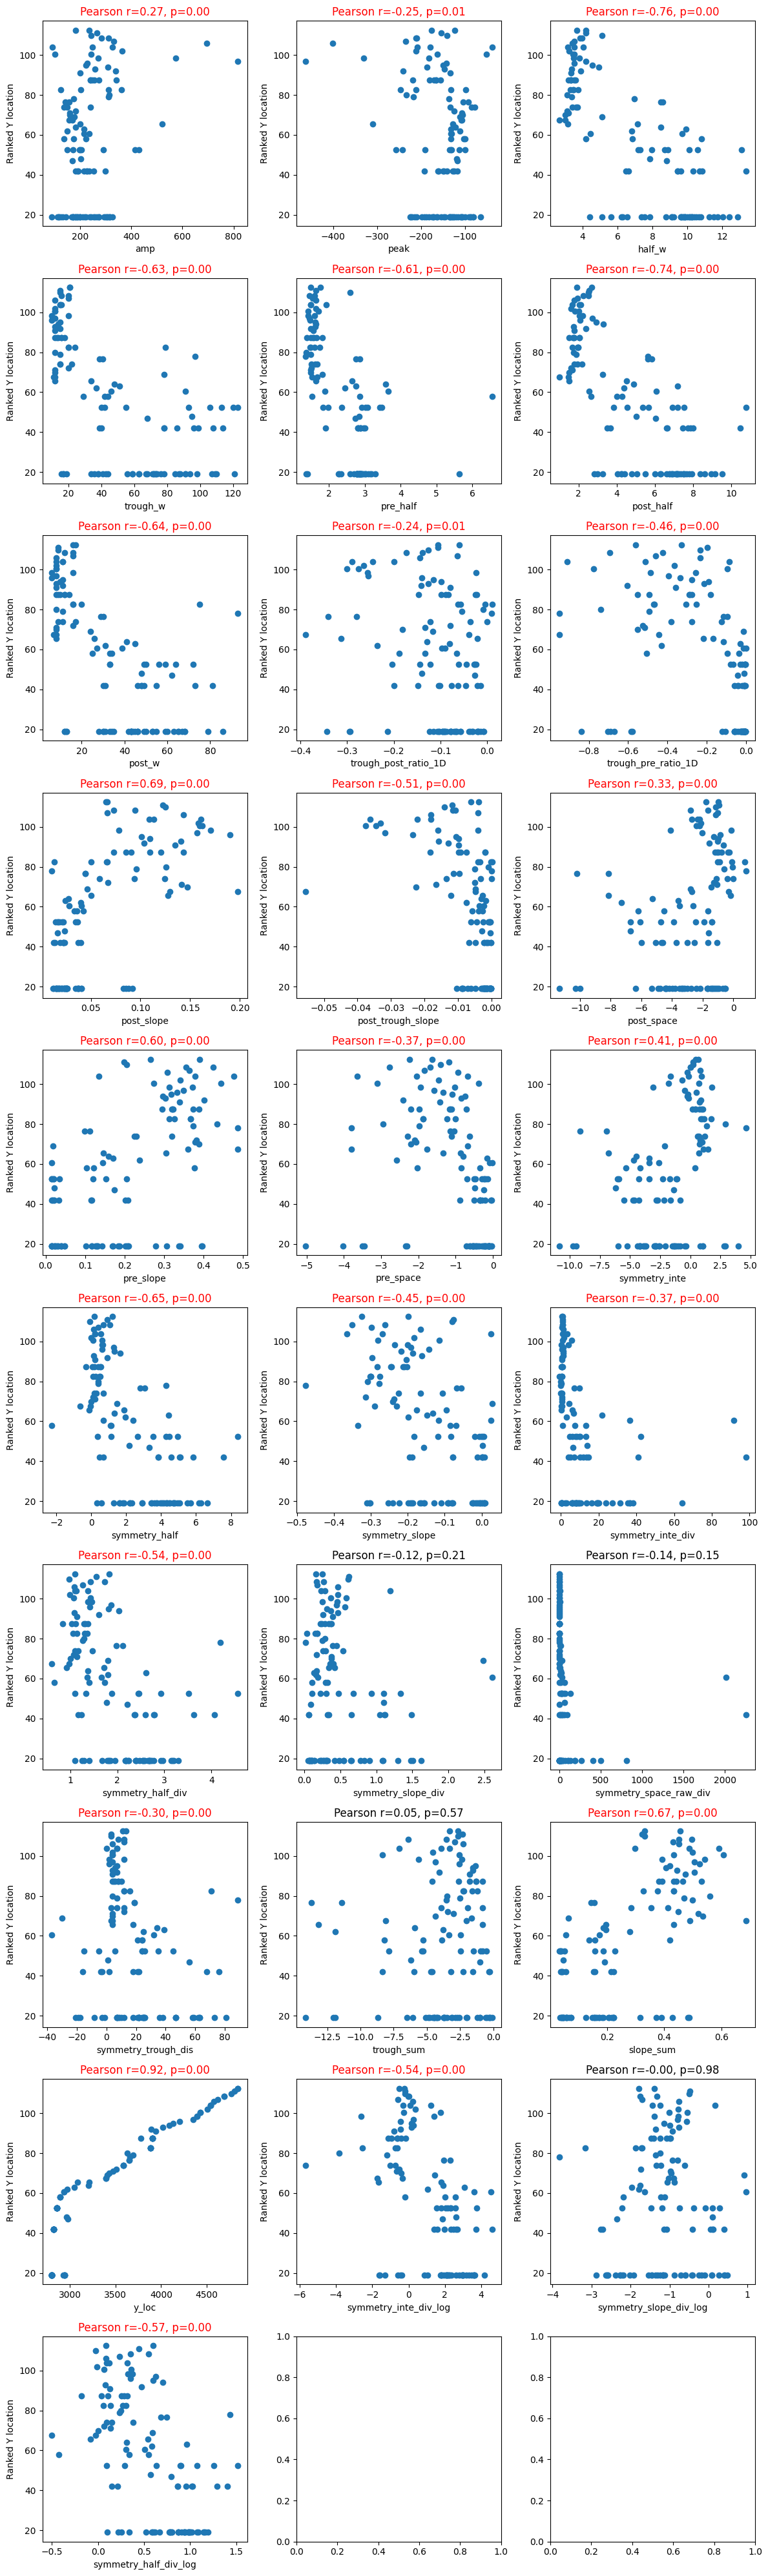

In [ ]:
# scatter plot and correlation with ranked 
features = wf_features.columns.tolist()
features.remove('unit')
features.remove('session')
features.remove('probe')
n_rows = int(np.ceil(len(features)/3))
fig, axes = plt.subplots(nrows=n_rows, ncols=3, figsize=(4*3, 4*n_rows))
for feature_ind, feature in enumerate(features):
    ax = axes[feature_ind // 3, feature_ind % 3]
    focus = wf_features[feature].values
    sc = ax.scatter(focus, y_loc_ranked)
    ax.set_xlabel(feature)
    ax.set_ylabel('Ranked Y location')
    # calculate pearson correlation
    valid_ind = ~np.isnan(focus)
    corr, pval = stats.pearsonr(focus[valid_ind], y_loc_ranked[valid_ind])
    if pval<=0.05:
        title_color = 'red'
    else:
        title_color = 'black'

    ax.set_title(f'Pearson r={corr:.2f}, p={pval:.2f}', color=title_color)
plt.tight_layout()
save_panels(fig, target_folder, f'Wf_features_vs_Yloc', ['FigureS14i'], exts=('pdf',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1: scatter, ranked depth vs each waveform feature) ----
_cols = {'y_loc_ranked': np.asarray(y_loc_ranked)}
for _f in features:
    _cols[_f] = wf_features[_f].values
save_panel_csv(columns_to_df(**_cols), target_folder, f'Wf_features_vs_Yloc', ['FigureS14i'])
##FigureS14i##

## Feature-based PCA and Dimensionality Reduction

Perform PCA on extracted waveform features (rather than raw waveforms) to identify composite measures that best capture variation. This approach reduces dimensionality while retaining interpretable relationships between specific waveform properties and spatial location.

In [26]:
# pca on focus features
focus_features_correct = ['half_w', 'pre_half', 'post_w', 
                'trough_post_ratio_1D', 'post_trough_slope', 'trough_pre_ratio_1D', 'pre_slope',
                'symmetry_slope_div_log','symmetry_trough_dis'
                ]
focus_features = focus_features_correct

In [27]:
 
 focus_features = [
                'post_w', 
                'trough_post_ratio_1D', 
                'post_trough_slope', 
                'pre_slope',
                'symmetry_slope_div_log',
                'symmetry_trough_dis', 
                'symmetry_inte_div_log', 
                ]


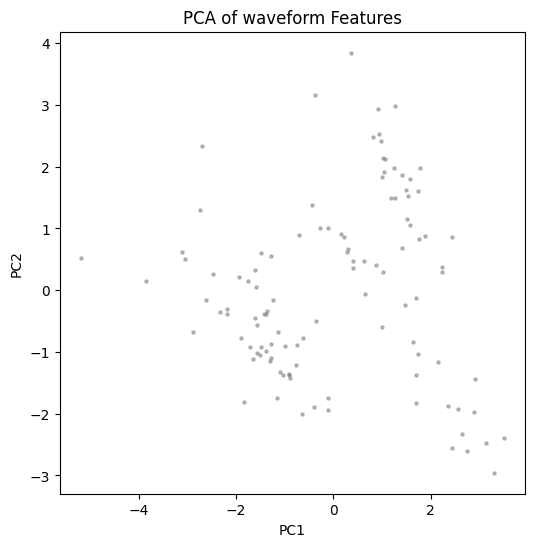

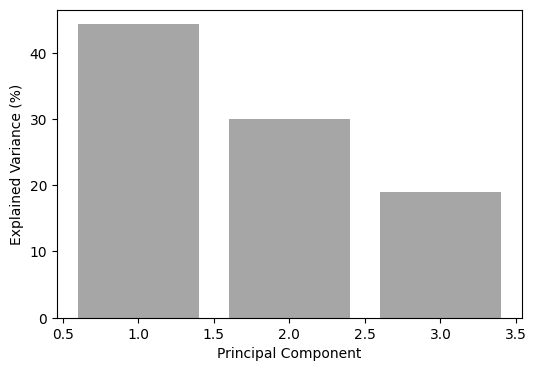

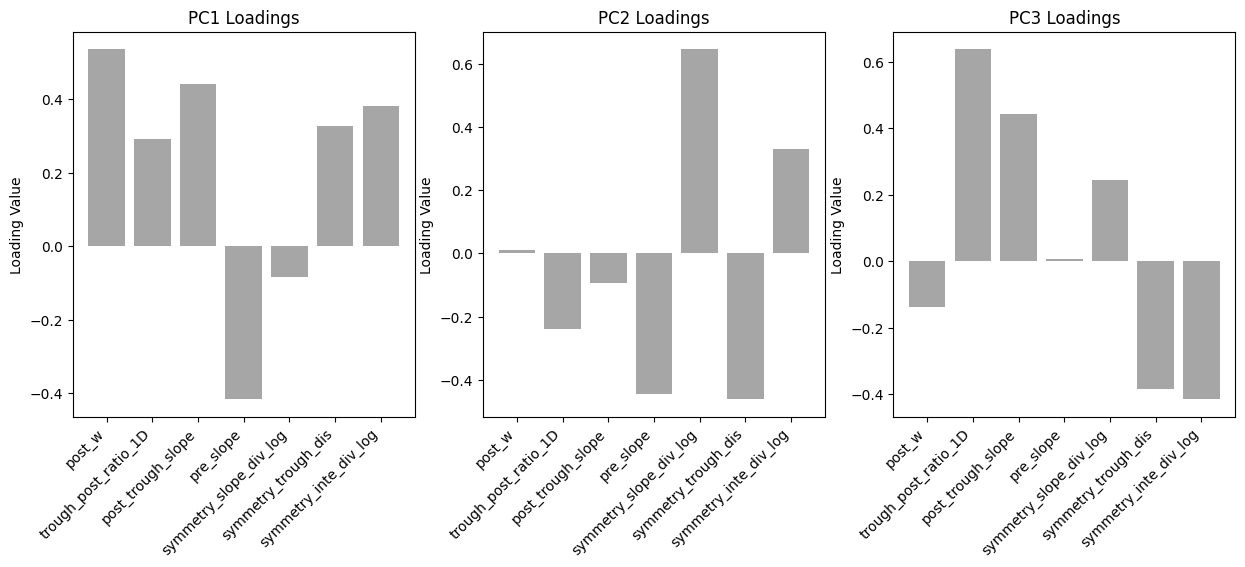

In [28]:
from sklearn.decomposition import PCA
feature_mat = wf_features[focus_features].values
# remove rows with nan
nan_ind = np.isnan(feature_mat).any(axis=1)
feature_mat = feature_mat[~nan_ind]
# zscore
from scipy.stats import zscore
feature_mat = zscore(feature_mat, axis=0, nan_policy='omit')

pca = PCA(n_components=3)
pca_result = pca.fit_transform(feature_mat)
# plot
fig = plt.figure(figsize=(6, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='gray', alpha=0.5, s=5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of waveform Features')
# plot explained variance ratio
explained_var = pca.explained_variance_ratio_
fig = plt.figure(figsize=(6, 4))
plt.bar(range(1, len(explained_var)+1), explained_var*100, color='gray', alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')

# plot how each features contribute to each PC, plot by PC
components = pca.components_
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    ax = axes[i]
    ax.bar(focus_features, components[i], color='gray', alpha=0.7)
    ax.set_title(f'PC{i+1} Loadings')
    ax.set_ylabel('Loading Value')
    ax.set_xticklabels(focus_features, rotation=45, ha='right')

## Spatial Mapping of Waveform Features

Generate final visualizations showing how waveform PCs relate to anatomical position. Binned waveform averages and scatter plots reveal whether systematic spatial gradients exist in spike shape properties across the tetrode recording sites.

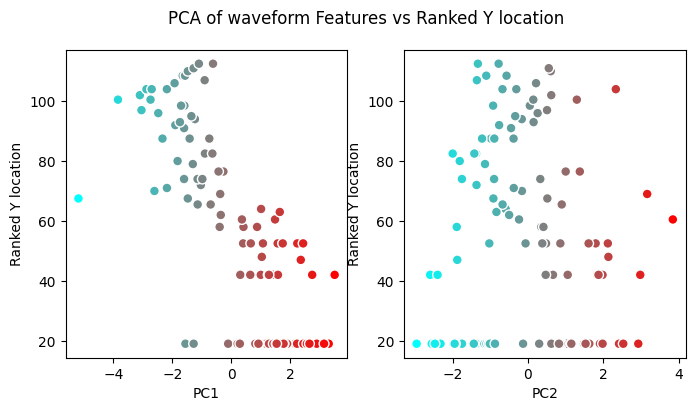

In [ ]:
# scatter plot of PC1 and PC2 against ranked y location
y_loc_ranked_no_nan = y_loc_ranked[~nan_ind]
custom_cmap = LinearSegmentedColormap.from_list('my_cmap', 
                                               [(0, (0, 1, 1)), 
                                                (0.5, (0.5, 0.5, 0.5)), 
                                                (1.0, (1, 0, 0))])
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(pca_result[:, 0], y_loc_ranked_no_nan, 
                c=pca_result[:, 0], cmap = custom_cmap, 
                alpha=1, s=50, edgecolors='w', linewidths=1)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('Ranked Y location')
axes[1].scatter(pca_result[:, 1], y_loc_ranked_no_nan, 
                c=pca_result[:, 1], cmap = custom_cmap, 
                alpha=1, s=50, edgecolors='w', linewidths=1)
axes[1].set_xlabel('PC2')
axes[1].set_ylabel('Ranked Y location')
plt.suptitle('PCA of waveform Features vs Ranked Y location')
save_panels(fig, target_folder, f'Wf_features_PCA_vs_Yloc', ['FigureS14g'], exts=('pdf',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1: scatter, PC1/PC2 vs ranked depth; color = PC value) ----
save_panel_csv(columns_to_df(PC1=pca_result[:, 0], PC2=pca_result[:, 1], y_loc_ranked=y_loc_ranked_no_nan), target_folder, f'Wf_features_PCA_vs_Yloc', ['FigureS14g'])
##FigureS14g##


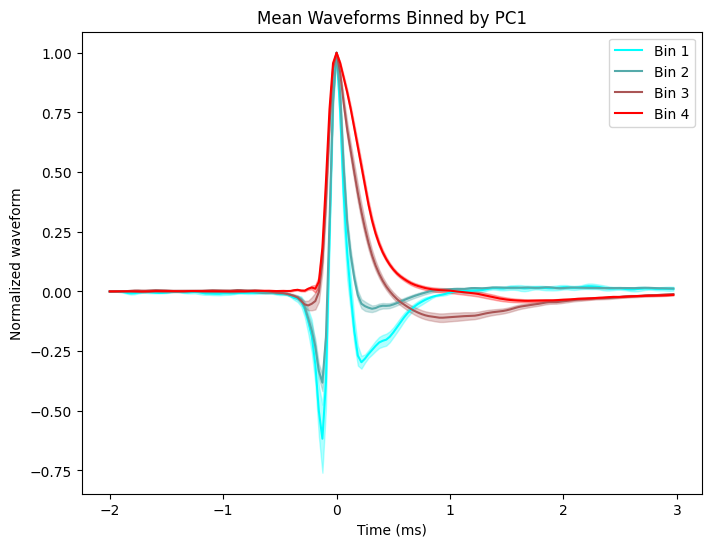

In [ ]:
# mean waveforms of binned by PC1
focus_value = pca_result[:, 0]
n_bins = 4
bins = np.linspace(np.min(focus_value), np.max(focus_value), n_bins+1)

fig = plt.figure(figsize=(8, 6))
for bin in range(n_bins):
    bin_ind = (focus_value >= bins[bin]) & (focus_value < bins[bin+1])
    mean_wf = np.nanmean(all_wfs_nl_clean[~nan_ind][bin_ind], axis=0)
    sem_wf = stats.sem(all_wfs_nl_clean[~nan_ind][bin_ind], axis=0, nan_policy='omit')
    color = custom_cmap(bin / (n_bins - 1))
    plt.plot(time, mean_wf, color=color, label=f'Bin {bin+1}')
    plt.fill_between(time, mean_wf - sem_wf, mean_wf + sem_wf, color=color, alpha=0.3)
plt.xlabel('Time (ms)')
plt.ylabel('Normalized waveform')
plt.title('Mean Waveforms Binned by PC1')
plt.legend()
save_panels(fig, target_folder, f'Wf_mean_binned_by_PC1', ['FigureS14h'], exts=('pdf',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 2: filled psth, mean+/-sem waveform per PC1 bin) ----
_fv = pca_result[:, 0]; _bins = np.linspace(np.min(_fv), np.max(_fv), n_bins + 1)
_bt = {'time_ms': np.asarray(time)}
for _b in range(n_bins):
    _bi = (_fv >= _bins[_b]) & (_fv < _bins[_b + 1])
    _bt[f'bin_{_b + 1}_mean'] = np.nanmean(all_wfs_nl_clean[~nan_ind][_bi], axis=0)
    _bt[f'bin_{_b + 1}_sem'] = stats.sem(all_wfs_nl_clean[~nan_ind][_bi], axis=0, nan_policy='omit')
save_panel_csv(columns_to_df(**_bt), target_folder, f'Wf_mean_binned_by_PC1', ['FigureS14h'])
##FigureS14h##